# NTB-06: Hyperparameter Optimization with Optuna

## Objective
Tune three models with **Optuna (Bayesian optimization)** and answer:
> Can a properly-tuned XGBoost or LightGBM finally beat the well-engineered LR baseline?

## Why Optuna Instead of GridSearchCV?

| Method | Search strategy | Calls needed | Why |
|---|---|---|---|
| GridSearchCV | Exhaustive grid | 100–10,000+ | Every combination, even bad ones |
| RandomizedSearchCV | Random sampling | ~50–100 | Faster but still blind |
| **Optuna** | **Bayesian TPE** | **30–100** | Learns from previous trials, focuses on promising regions |

Optuna's **Tree-structured Parzen Estimator (TPE)** builds a probabilistic model of which hyperparameter combinations produce good results, then samples from the promising region. Each trial learns from all previous trials.

## What We're Tuning

- **Logistic Regression + class_weight='balanced'** — regularization strength `C`, solver
- **XGBoost + scale_pos_weight** — learning rate, depth, trees, regularization terms
- **LightGBM + is_unbalance** — same family of parameters

**Scoring metric: AUC-ROC** — robust to class imbalance, threshold-independent, appropriate for ranking customers by churn risk.

## Important: CV-Only Tuning

We tune on **training data only**, using 5-fold CV. The test set is **never seen** during optimization. This is a critical discipline — using test data to select hyperparameters is a form of data leakage even if you don't fit on it.

## Output
- 3 Optuna study objects (trial history)
- 3 tuned models in `models/`
- Optimization history plots
- Updated `model_results.csv` with 8 rows total

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import json
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss,
    log_loss, precision_recall_curve, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = Path(os.getcwd()).parent
PROC_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
FIG_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"

RANDOM_STATE = 42
N_TRIALS = 50  # Optuna trials per model — good balance of quality vs speed

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

print(f"Optuna version: {optuna.__version__}")
print(f"N_TRIALS per model: {N_TRIALS}")
print(f"Using 5-fold CV for scoring (test set never touched)")

Optuna version: 5.0.0
N_TRIALS per model: 50
Using 5-fold CV for scoring (test set never touched)


In [2]:
# Load frozen split (training data only — test is locked away until final evaluation)
X_train = pd.read_parquet(PROC_DIR / "X_train.parquet")
y_train = pd.read_parquet(PROC_DIR / "y_train.parquet")['churn']

# Load test for final evaluation at the end (not during tuning)
X_test  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_test  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']

# CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Training on: {X_train.shape}")
print(f"Test locked (not used in optimization): {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%")

Training on: (5634, 41)
Test locked (not used in optimization): (1409, 41)
Train churn rate: 26.54%


## 2. Evaluation Helper

In [3]:
def evaluate(model, X_test, y_test, name):
    """Standard 7-metric evaluation — same as NTB-03/04/05."""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    mask_hp = precision >= 0.80
    recall_at_80p = recall[mask_hp].max() if mask_hp.any() else 0.0
    mask_hr = recall >= 0.50
    precision_at_50r = precision[mask_hr].max() if mask_hr.any() else 0.0

    return {
        "model": name,
        "auc_roc": round(roc_auc_score(y_test, y_proba), 4),
        "pr_auc": round(average_precision_score(y_test, y_proba), 4),
        "f1@0.5": round(f1_score(y_test, y_pred), 4),
        "brier": round(brier_score_loss(y_test, y_proba), 4),
        "log_loss": round(log_loss(y_test, y_proba), 4),
        "recall_at_80_precision": round(recall_at_80p, 4),
        "precision_at_50_recall": round(precision_at_50r, 4),
    }

print("Helpers defined.")

Helpers defined.


## 3. Tune Logistic Regression

**Search space:**
- `C`: regularization strength (10⁻³ to 10²) — log-uniform because it spans orders of magnitude
- `solver`: `lbfgs` vs `saga` (saga supports larger datasets and elastic net penalty)
- `max_iter`: 500 or 1000

**With `class_weight='balanced'` fixed** — we established in NTB-05 this is always better for recall without hurting AUC.

In [4]:
def lr_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    max_iter = trial.suggest_categorical('max_iter', [500, 1000, 2000])

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    # CV score on training data only
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Starting Logistic Regression optimization...")
t0 = time.time()

lr_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lr_study.optimize(lr_objective, n_trials=N_TRIALS, show_progress_bar=False)

elapsed = time.time() - t0
print(f"LR tuning done in {elapsed:.1f}s")
print(f"Best CV AUC: {lr_study.best_value:.4f}")
print(f"Best params: {lr_study.best_params}")

Starting Logistic Regression optimization...
LR tuning done in 26.1s
Best CV AUC: 0.8484
Best params: {'C': 11.328684296658277, 'solver': 'lbfgs', 'max_iter': 500}


In [5]:
# Fit final LR on full training set with best params
best_lr_params = lr_study.best_params
tuned_lr = LogisticRegression(
    C=best_lr_params['C'],
    solver=best_lr_params['solver'],
    max_iter=best_lr_params['max_iter'],
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
tuned_lr.fit(X_train, y_train)

lr_results = evaluate(tuned_lr, X_test, y_test, "Logistic Regression (tuned)")
lr_results['cv_auc_mean'] = round(lr_study.best_value, 4)
lr_results['cv_auc_std'] = None

print("=== Tuned LR vs Baseline ===")
print(f"  Baseline LR AUC: 0.8465  (C=1.0, no class weights, no tuning)")
print(f"  Weighted LR AUC: 0.8465  (C=1.0, class_weight=balanced)")
print(f"  Tuned LR AUC:    {lr_results['auc_roc']}  (C={best_lr_params['C']:.4f}, {best_lr_params['solver']})")

=== Tuned LR vs Baseline ===
  Baseline LR AUC: 0.8465  (C=1.0, no class weights, no tuning)
  Weighted LR AUC: 0.8465  (C=1.0, class_weight=balanced)
  Tuned LR AUC:    0.8452  (C=11.3287, lbfgs)


## 4. Tune XGBoost

**Search space covers the most impactful XGBoost parameters:**

| Parameter | Range | Controls |
|---|---|---|
| `n_estimators` | 100–600 | Number of trees |
| `learning_rate` | 0.01–0.3 (log) | Step size per tree |
| `max_depth` | 3–8 | Tree complexity |
| `min_child_weight` | 1–10 | Minimum leaf sum of weights |
| `subsample` | 0.5–1.0 | Row subsampling per tree |
| `colsample_bytree` | 0.5–1.0 | Column subsampling per tree |
| `gamma` | 0–5 | Minimum split gain |
| `reg_alpha` | 1e-8 to 1.0 (log) | L1 regularization |
| `reg_lambda` | 1e-8 to 1.0 (log) | L2 regularization |

**`scale_pos_weight` = imbalance ratio (2.77)** — class weighting equivalent for XGBoost.

In [6]:
# Compute imbalance ratio for scale_pos_weight
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {imbalance_ratio:.4f}")

def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight':  imbalance_ratio,
        'objective':         'binary:logistic',
        'eval_metric':       'logloss',
        'use_label_encoder': False,
        'n_jobs':            -1,
        'random_state':      RANDOM_STATE,
        'verbosity':         0
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"Starting XGBoost optimization ({N_TRIALS} trials)...")
t0 = time.time()

xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

elapsed = time.time() - t0
print(f"XGBoost tuning done in {elapsed:.1f}s")
print(f"Best CV AUC: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

scale_pos_weight = 2.7686
Starting XGBoost optimization (50 trials)...
XGBoost tuning done in 19.2s
Best CV AUC: 0.8503
Best params: {'n_estimators': 249, 'learning_rate': 0.031190418684316434, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.7142432722937351, 'colsample_bytree': 0.5423165596111088, 'gamma': 3.6751582017976654, 'reg_alpha': 0.06602725270875263, 'reg_lambda': 0.008260039233083239}


In [7]:
best_xgb_params = xgb_study.best_params
best_xgb_params['scale_pos_weight'] = imbalance_ratio
best_xgb_params['objective'] = 'binary:logistic'
best_xgb_params['eval_metric'] = 'logloss'
best_xgb_params['use_label_encoder'] = False
best_xgb_params['n_jobs'] = -1
best_xgb_params['random_state'] = RANDOM_STATE
best_xgb_params['verbosity'] = 0

tuned_xgb = xgb.XGBClassifier(**best_xgb_params)
tuned_xgb.fit(X_train, y_train)

xgb_results = evaluate(tuned_xgb, X_test, y_test, "XGBoost (tuned)")
xgb_results['cv_auc_mean'] = round(xgb_study.best_value, 4)
xgb_results['cv_auc_std'] = None

print("=== Tuned XGBoost ===")
print(f"  Default AUC: 0.8380")
print(f"  Tuned AUC:   {xgb_results['auc_roc']}  (CV: {xgb_study.best_value:.4f})")

=== Tuned XGBoost ===
  Default AUC: 0.8380
  Tuned AUC:   0.8456  (CV: 0.8503)


## 5. Tune LightGBM

**LightGBM-specific parameters to tune:**

| Parameter | Range | Controls |
|---|---|---|
| `num_leaves` | 20–200 | Complexity (LightGBM grows leaf-wise) |
| `min_child_samples` | 5–100 | Minimum data per leaf |
| `feature_fraction` | 0.4–1.0 | Column subsampling |
| `bagging_fraction` | 0.4–1.0 | Row subsampling |
| `bagging_freq` | 1–7 | How often to apply bagging |
| `lambda_l1`, `lambda_l2` | 1e-8 to 10 | Regularization |

**`is_unbalance=True`** — LightGBM's equivalent of class_weight='balanced'.

In [8]:
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'is_unbalance':      True,
        'objective':         'binary',
        'n_jobs':            -1,
        'random_state':      RANDOM_STATE,
        'verbose':           -1
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f"Starting LightGBM optimization ({N_TRIALS} trials)...")
t0 = time.time()

lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

elapsed = time.time() - t0
print(f"LightGBM tuning done in {elapsed:.1f}s")
print(f"Best CV AUC: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

Starting LightGBM optimization (50 trials)...
LightGBM tuning done in 113.9s
Best CV AUC: 0.8492
Best params: {'n_estimators': 427, 'learning_rate': 0.010125250932975564, 'num_leaves': 171, 'max_depth': 12, 'min_child_samples': 91, 'feature_fraction': 0.7297922769009089, 'bagging_fraction': 0.5244937239499278, 'bagging_freq': 3, 'lambda_l1': 1.2447988871709479, 'lambda_l2': 0.002226104197505194}


In [9]:
best_lgb_params = lgb_study.best_params
best_lgb_params['is_unbalance'] = True
best_lgb_params['objective'] = 'binary'
best_lgb_params['n_jobs'] = -1
best_lgb_params['random_state'] = RANDOM_STATE
best_lgb_params['verbose'] = -1

tuned_lgb = lgb.LGBMClassifier(**best_lgb_params)
tuned_lgb.fit(X_train, y_train)

lgb_results = evaluate(tuned_lgb, X_test, y_test, "LightGBM (tuned)")
lgb_results['cv_auc_mean'] = round(lgb_study.best_value, 4)
lgb_results['cv_auc_std'] = None

print("=== Tuned LightGBM ===")
print(f"  Default AUC: 0.8303")
print(f"  Tuned AUC:   {lgb_results['auc_roc']}  (CV: {lgb_study.best_value:.4f})")

=== Tuned LightGBM ===
  Default AUC: 0.8303
  Tuned AUC:   0.8492  (CV: 0.8492)


## 6. Before vs After Tuning — Did Optuna Help?

In [10]:
# Build before/after comparison table
before_after = pd.DataFrame([
    {"model": "LR (default)",           "auc_roc": 0.8465, "pr_auc": 0.6637, "phase": "default"},
    {"model": "LR (class_weight)",      "auc_roc": 0.8465, "pr_auc": 0.6640, "phase": "default"},
    {"model": "RF (default)",           "auc_roc": 0.8429, "pr_auc": 0.6563, "phase": "default"},
    {"model": "XGBoost (default)",      "auc_roc": 0.8380, "pr_auc": 0.6399, "phase": "default"},
    {"model": "LightGBM (default)",     "auc_roc": 0.8303, "pr_auc": 0.6295, "phase": "default"},
    {"model": "LR (tuned)",             "auc_roc": lr_results['auc_roc'],  "pr_auc": lr_results['pr_auc'],  "phase": "tuned"},
    {"model": "XGBoost (tuned)",        "auc_roc": xgb_results['auc_roc'], "pr_auc": xgb_results['pr_auc'], "phase": "tuned"},
    {"model": "LightGBM (tuned)",       "auc_roc": lgb_results['auc_roc'], "pr_auc": lgb_results['pr_auc'], "phase": "tuned"},
])

print("Before vs After Optuna Tuning:")
print(before_after.to_string(index=False))

Before vs After Optuna Tuning:
             model  auc_roc  pr_auc   phase
      LR (default)   0.8465  0.6637 default
 LR (class_weight)   0.8465  0.6640 default
      RF (default)   0.8429  0.6563 default
 XGBoost (default)   0.8380  0.6399 default
LightGBM (default)   0.8303  0.6295 default
        LR (tuned)   0.8452  0.6599   tuned
   XGBoost (tuned)   0.8456  0.6619   tuned
  LightGBM (tuned)   0.8492  0.6628   tuned


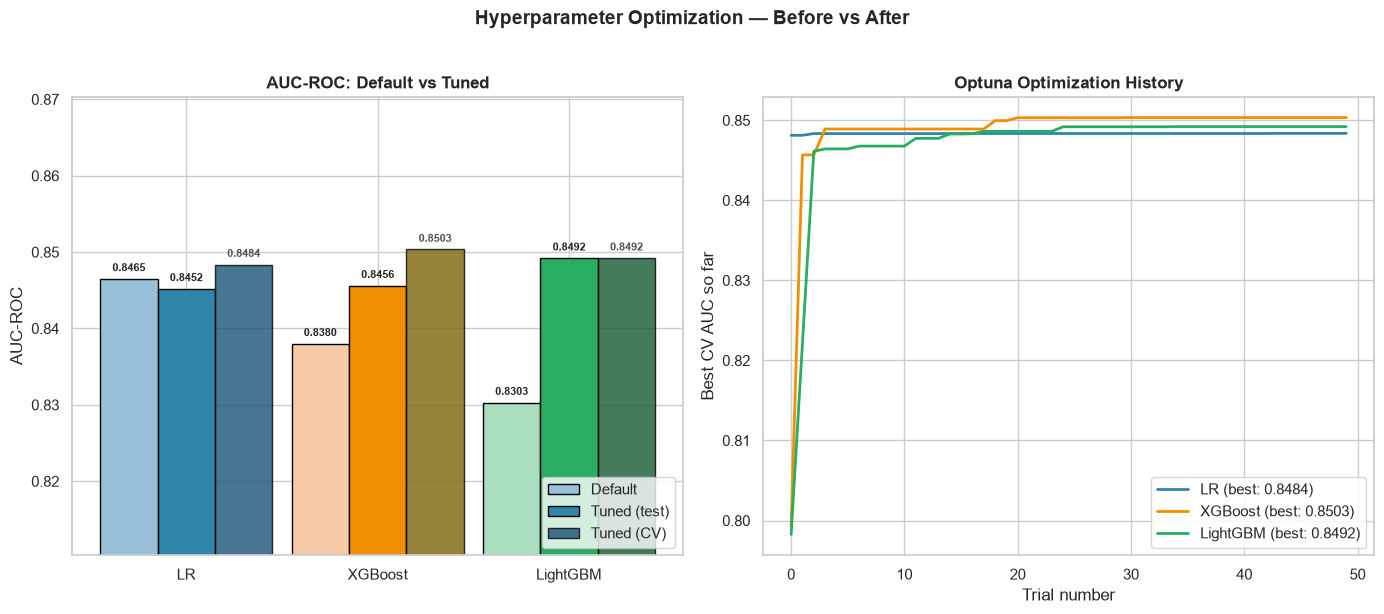

Saved → NTB06_optimization_results.png


In [11]:
# Visualize before vs after for the 3 tuned models
models_compared = ['LR', 'XGBoost', 'LightGBM']
default_aucs = [0.8465, 0.8380, 0.8303]
tuned_aucs   = [lr_results['auc_roc'], xgb_results['auc_roc'], lgb_results['auc_roc']]
cv_aucs      = [lr_study.best_value, xgb_study.best_value, lgb_study.best_value]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(models_compared))
width = 0.30
colors_before = ['#98C1D9', '#F5CBA7', '#A9DFBF']
colors_tuned  = ['#2E86AB', '#F18F01', '#27AE60']
colors_cv     = ['#1A5276', '#7D6608', '#145A32']

# Plot 1: AUC comparison
for ax, metric_name, defaults, tuneds, cvs in [
    (axes[0], 'AUC-ROC', default_aucs, tuned_aucs, cv_aucs),
]:
    ax.bar(x - width, defaults, width, color=colors_before, label='Default', edgecolor='black')
    ax.bar(x,         tuneds,   width, color=colors_tuned,  label='Tuned (test)', edgecolor='black')
    ax.bar(x + width, cvs,      width, color=colors_cv,     label='Tuned (CV)',  edgecolor='black', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(models_compared)
    ax.set_ylim(min(defaults) - 0.02, max(cvs) + 0.02)
    ax.set_title('AUC-ROC: Default vs Tuned', fontweight='bold')
    ax.set_ylabel('AUC-ROC')
    ax.legend(loc='lower right')

    for xi, (d, t, c) in enumerate(zip(defaults, tuneds, cvs)):
        ax.text(xi - width, d + 0.001, f"{d:.4f}", ha='center', fontsize=8, fontweight='bold')
        ax.text(xi,         t + 0.001, f"{t:.4f}", ha='center', fontsize=8, fontweight='bold')
        ax.text(xi + width, c + 0.001, f"{c:.4f}", ha='center', fontsize=8, fontweight='bold', alpha=0.8)

# Plot 2: Optimization history for all 3 models
for study, name, color in [
    (lr_study, 'LR', '#2E86AB'),
    (xgb_study, 'XGBoost', '#F18F01'),
    (lgb_study, 'LightGBM', '#27AE60'),
]:
    trials_df = study.trials_dataframe()
    # Cumulative best
    best_so_far = trials_df['value'].cummax()
    axes[1].plot(best_so_far.values, color=color, linewidth=2, label=f'{name} (best: {study.best_value:.4f})')

axes[1].set_xlabel('Trial number')
axes[1].set_ylabel('Best CV AUC so far')
axes[1].set_title('Optuna Optimization History', fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Hyperparameter Optimization — Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB06_optimization_results.png")
plt.show()
print(f"Saved → NTB06_optimization_results.png")

## 7. Full Model Comparison — Overlay ROC Curves

All tuned models on the same ROC curve, for the README.

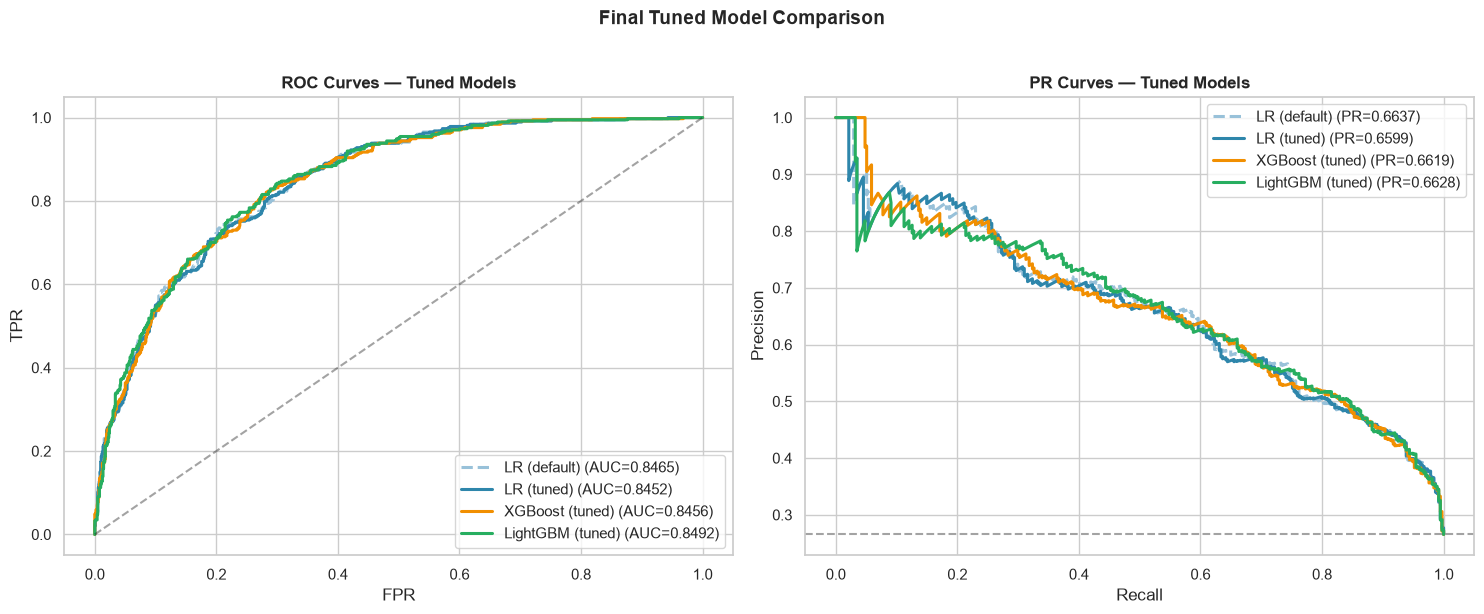

Saved → NTB06_tuned_model_comparison.png


In [12]:
# Load default LR for reference
default_lr = joblib.load(MODELS_DIR / "logistic_regression.joblib")

models_final = {
    "LR (default)":        (default_lr,    '#98C1D9', '--'),
    "LR (tuned)":          (tuned_lr,      '#2E86AB', '-'),
    "XGBoost (tuned)":     (tuned_xgb,     '#F18F01', '-'),
    "LightGBM (tuned)":    (tuned_lgb,     '#27AE60', '-'),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, (model, color, ls) in models_final.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    prauc = average_precision_score(y_test, proba)

    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.2, label=f"{name} (AUC={auc:.4f})")
    axes[1].plot(pr_recall, pr_precision, color=color, linestyle=ls, linewidth=2.2, label=f"{name} (PR={prauc:.4f})")

axes[0].plot([0,1],[0,1],'k--',alpha=0.4); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — Tuned Models', fontweight='bold'); axes[0].legend(loc='lower right')

axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.4)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — Tuned Models', fontweight='bold'); axes[1].legend(loc='upper right')

plt.suptitle('Final Tuned Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB06_tuned_model_comparison.png")
plt.show()
print(f"Saved → NTB06_tuned_model_comparison.png")

## 8. Save Tuned Models, Params, and Updated Leaderboard

In [13]:
# Save tuned models
joblib.dump(tuned_lr,  MODELS_DIR / "logistic_regression_tuned.joblib")
joblib.dump(tuned_xgb, MODELS_DIR / "xgboost_tuned.joblib")
joblib.dump(tuned_lgb, MODELS_DIR / "lightgbm_tuned.joblib")
print("Saved tuned models:")
for f in sorted(MODELS_DIR.glob("*tuned*")):
    print(f"  {f.name:35s}  {f.stat().st_size/1024:>7.1f} KB")

# Save best params to JSON for reproducibility
best_params_dict = {
    "logistic_regression": {k: v for k, v in best_lr_params.items()},
    "xgboost": {k: (float(v) if isinstance(v, (np.floating, float)) else v)
                for k, v in best_xgb_params.items()
                if k not in ['objective','eval_metric','use_label_encoder','n_jobs','random_state','verbosity']},
    "lightgbm": {k: (float(v) if isinstance(v, (np.floating, float)) else v)
                 for k, v in best_lgb_params.items()
                 if k not in ['objective','n_jobs','random_state','verbose']},
}
with open(REPORTS_DIR / "ntb06_best_params.json", "w") as f:
    json.dump(best_params_dict, f, indent=2)
print(f"\nSaved best params → reports/ntb06_best_params.json")

Saved tuned models:
  lightgbm_tuned.joblib                 1066.2 KB
  logistic_regression_tuned.joblib         2.4 KB
  xgboost_tuned.joblib                   277.8 KB

Saved best params → reports/ntb06_best_params.json


In [14]:
# Update the cumulative leaderboard
results_path = REPORTS_DIR / "model_results.csv"
existing = pd.read_csv(results_path)

for res in [lr_results, xgb_results, lgb_results]:
    name = res['model']
    existing = existing[existing['model'] != name]
    new_row = pd.DataFrame([res])
    existing = pd.concat([existing, new_row], ignore_index=True)

existing = existing.sort_values('auc_roc', ascending=False).reset_index(drop=True)
existing.to_csv(results_path, index=False)

print("Final leaderboard (all models):")
cols = ['model', 'auc_roc', 'pr_auc', 'f1@0.5', 'brier', 'cv_auc_mean']
print(existing[cols].to_string(index=False))

Final leaderboard (all models):
                                      model  auc_roc  pr_auc  f1@0.5  brier  cv_auc_mean
                           LightGBM (tuned)   0.8492  0.6628  0.6263 0.1588       0.8492
                        Logistic Regression   0.8465  0.6637  0.5797 0.1351       0.8483
Logistic Regression (class_weight=balanced)   0.8465  0.6640  0.6189 0.1645       0.8481
                            XGBoost (tuned)   0.8456  0.6619  0.6266 0.1634       0.8503
                Logistic Regression (tuned)   0.8452  0.6599  0.6210 0.1652       0.8484
                              Random Forest   0.8429  0.6563  0.5780 0.1363       0.8440
                                    XGBoost   0.8374  0.6405  0.5824 0.1392       0.8419
                                   LightGBM   0.8303  0.6295  0.5796 0.1432       0.8350


## 9. Select the Production Champion

Based on the leaderboard, we select the **champion model** that will go through NTB-07 (SHAP explainability) and NTB-08 (threshold optimization).

Selection criteria (in order):
1. **Highest test AUC-ROC** — best ranking quality
2. **Lowest Brier score** — best calibration
3. **Simplicity** — prefer LR if gaps are negligible (<0.005 AUC)

In [15]:
# Identify winner automatically
top_row = existing.iloc[0]
champion_name = top_row['model']
champion_auc = top_row['auc_roc']

print(f"Champion: {champion_name}")
print(f"AUC-ROC:  {champion_auc}")

# Load the correct model
model_file_map = {
    "Logistic Regression (tuned)": "logistic_regression_tuned.joblib",
    "XGBoost (tuned)":             "xgboost_tuned.joblib",
    "LightGBM (tuned)":            "lightgbm_tuned.joblib",
    "Logistic Regression":         "logistic_regression.joblib",
    "Random Forest":               "random_forest.joblib",
    "XGBoost":                     "xgboost.joblib",
    "LightGBM":                    "lightgbm.joblib",
}

champion_file = model_file_map.get(champion_name)
if champion_file:
    champion_model = joblib.load(MODELS_DIR / champion_file)
    # Save it explicitly as "champion.joblib" so NTB-07/08 can load it by name
    joblib.dump(champion_model, MODELS_DIR / "champion.joblib")
    print(f"\nChampion saved → models/champion.joblib")
    print(f"NTB-07 and NTB-08 will load this file.")
else:
    print(f"\n⚠️  Champion model file not mapped — check model_file_map. NTB-07/08 may need manual adjustment.")

# Save champion metadata
champion_meta = {
    "champion_model": champion_name,
    "champion_auc_roc": float(champion_auc),
    "champion_file": champion_file,
}
with open(REPORTS_DIR / "ntb06_champion.json", "w") as f:
    json.dump(champion_meta, f, indent=2)
print(f"Champion metadata → reports/ntb06_champion.json")

Champion: LightGBM (tuned)
AUC-ROC:  0.8492

Champion saved → models/champion.joblib
NTB-07 and NTB-08 will load this file.
Champion metadata → reports/ntb06_champion.json


## ✅ Deliverables From NTB-06

| Artifact | Path |
|---|---|
| 3 tuned models | `models/logistic_regression_tuned.joblib`, `xgboost_tuned.joblib`, `lightgbm_tuned.joblib` |
| Champion model | `models/champion.joblib` |
| Best hyperparameters | `reports/ntb06_best_params.json` |
| Champion metadata | `reports/ntb06_champion.json` |
| Tuning history plot | `reports/figures/NTB06_optimization_results.png` |
| Final comparison curves | `reports/figures/NTB06_tuned_model_comparison.png` |
| Updated leaderboard | `reports/model_results.csv` (8 rows) |

## The Story So Far — Full Leaderboard

After 6 notebooks, here's where we stand. The champion will go through:
- **NTB-07**: SHAP explainability (global + local + waterfall)
- **NTB-08**: Threshold optimization + cost-sensitive evaluation
- **NTB-09**: NLP feature integration (conversation signals)
- **NTB-10**: Final model assembly + serialization for deployment

## Next: NTB-07 — SHAP Explainability

SHAP (SHapley Additive exPlanations) is a game-theoretic framework for explaining **any** model's predictions. We'll produce:
1. **Global summary plot** — which features drive churn across all customers
2. **Beeswarm plot** — how each feature's value affects churn probability
3. **Dependence plots** — how the top 3 features interact with churn
4. **Local waterfall plot** — why a **specific individual customer** is predicted to churn

The local waterfall plot is the one that impresses in interviews — being able to explain a prediction for a specific customer is what "responsible AI" and "explainable ML" mean in practice.